# HATR: River vs CapyMOA

Verifica che l'implementazione Java produca le stesse predizioni di River a parità di parametri e dataset. Eseguire in ordine da kernel fresco.

## Setup

In [ ]:
import os
import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f'JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn package -DskipTests'

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    SIZEOF_JAR = os.path.expanduser(
        "~/.m2/repository/com/github/fracpete/sizeofag/1.1.0/sizeofag-1.1.0.jar")
    if os.path.exists(SIZEOF_JAR):
        os.environ["CAPYMOA_JVM_ARGS"] = (
            f"-Xmx8g -Xss10M -javaagent:{SIZEOF_JAR} " 
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
            "-XX:ErrorFile=/dev/null"
        )
    else:
        os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)
    print(f'classpath: {HATR_JAR}')

classpath: /Users/andreazhang/Desktop/sda/2025-2026_Regression-Models-in-CapyMOA/andrea_zhang/implementation/hatr-moa/target/hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error

from capymoa.stream import Schema
from capymoa.instance import RegressionInstance
from jpype import JClass

import utils_diagnostic as ud

try:
    JClass('moa.classifiers.trees.HoeffdingAdaptiveTreeRegressor')
    print('HoeffdingAdaptiveTreeRegressor ok')
except Exception as e:
    raise RuntimeError(f'Classe non trovata: {e} — Kernel -> Restart & Run All')

HoeffdingAdaptiveTreeRegressor ok


## Dataset

In [ ]:
N, DRIFT_AT, SEED = 2000, 1000, 42

rng = np.random.RandomState(SEED)
X = rng.randn(N, 3).astype(np.float64)
noise = 0.1 * rng.randn(N)

# Pre-drift:  y = 2·x0 + 3·x1 − x2
# Post-drift: y = −1.5·x0 + 0.5·x2 + 5
y = np.where(
    np.arange(N) < DRIFT_AT,
    2*X[:,0] + 3*X[:,1] - X[:,2] + noise,
   -1.5*X[:,0] + 0.5*X[:,2] + 5.0 + noise
)

feature_names = ['x0', 'x1', 'x2']
print(f'Dataset: {N} campioni, 3 feature, drift a {DRIFT_AT}')
print(f'y range: [{y.min():.2f}, {y.max():.2f}]')

Dataset: 2000 campioni, 3 feature, drift a 1000
y ∈ [-11.29, 12.88]


## Parametri

In [ ]:
PARAMS = dict(
    grace_period = 50,
    delta = 1e-7,
    tau = 0.05,
    leaf_prediction = 'mean',
    bootstrap_sampling = False,
    drift_window_threshold = 300,
    switch_significance = 0.05,
    min_samples_split = 5,
    model_selector_decay = 0.95,
    adwin_delta = 0.002,
    adwin_clock = 32,
)

USE_SCALER = True 

print(PARAMS)
print('USE_SCALER =', USE_SCALER)

{'grace_period': 50, 'delta': 1e-07, 'tau': 0.05, 'leaf_prediction': 'mean', 'bootstrap_sampling': False, 'drift_window_threshold': 300, 'switch_significance': 0.05, 'min_samples_split': 5, 'model_selector_decay': 0.95, 'adwin_delta': 0.002, 'adwin_clock': 32}
USE_SCALER = True


## River

In [5]:
from river import preprocessing, tree as river_tree, drift as river_drift

feature_names = ['x0', 'x1', 'x2']

river_m = ud.build_river(PARAMS)
river_preds, river_maes = ud.run_river(river_m, X, y, use_scaler=USE_SCALER,feature_names=feature_names)

rs = river_m.summary
print(f'River  MAE={river_maes[-1]:.6f}  nodes={rs["n_nodes"]}  leaves={rs["n_leaves"]}  alt_trees={rs["n_alternate_trees"]}')

River  MAE=1.289719  nodes=21  leaves=11  alt_trees=3


## CapyMOA

In [6]:
schema = Schema.from_custom(
    features=['x0', 'x1', 'x2', 'y'],
    target='y',
    categories=None,
    name='hatr_comparison'
)

def run_capymoa(model, X, y, schema, use_scaler=False):
    return ud.run_capymoa(model, X, y, schema, use_scaler=use_scaler, feature_names=feature_names)

capymoa_m = ud.build_capymoa(PARAMS, schema)
capymoa_preds, capymoa_maes = run_capymoa(capymoa_m, X, y, schema, use_scaler=USE_SCALER)

jh = capymoa_m.moa_learner
meas = {m.getName(): int(m.getValue()) for m in jh.getModelMeasurements()}
print(f'CapyMOA MAE={capymoa_maes[-1]:.6f}  nodes={meas["tree nodes"]}  leaves={meas["tree leaves"]}  alt_trees={meas["alternate trees"]}')

CapyMOA MAE=1.289719  nodes=21  leaves=11  alt_trees=3


## Confronto metriche

In [ ]:
SKIP = 10  

mae_r = mean_absolute_error(y[SKIP:], river_preds[SKIP:])
mae_c = mean_absolute_error(y[SKIP:], capymoa_preds[SKIP:])
rmse_r = np.sqrt(mean_squared_error(y[SKIP:], river_preds[SKIP:]))
rmse_c = np.sqrt(mean_squared_error(y[SKIP:], capymoa_preds[SKIP:]))

corr, _  = pearsonr(river_preds[SKIP:], capymoa_preds[SKIP:])
abs_diff = np.abs(river_preds - capymoa_preds)
n_identical = int(np.sum(abs_diff == 0))
n_near_ident = int(np.sum(abs_diff < 1e-9))

print(f"{'Metrica':<22} {'River':>12} {'CapyMOA':>12} {'Delta':>12}")
print('-' * 60)
print(f"{'MAE':<22} {mae_r:>12.8f} {mae_c:>12.8f} {abs(mae_r-mae_c):>12.2e}")
print(f"{'RMSE':<22} {rmse_r:>12.8f} {rmse_c:>12.8f} {abs(rmse_r-rmse_c):>12.2e}")
print(f"{'Pred correlation':<22} {corr:>12.8f}")
print(f"{'Max |pred diff|':<22} {abs_diff.max():>12.2e}")
print(f"{'Mean |pred diff|':<22} {abs_diff.mean():>12.2e}")
print(f"{'Pred identiche (==)':<22} {n_identical:>12d} / {N}")
print(f"{'Pred quasi-id (<1e-9)':<22} {n_near_ident:>12d} / {N}")

Metrica                       River      CapyMOA        Delta
------------------------------------------------------------
MAE                      1.27998341   1.27998341     0.00e+00
RMSE                     1.86441323   1.86441323     0.00e+00
Pred correlation         1.00000000
Max |pred diff|            0.00e+00
Mean |pred diff|           0.00e+00
Pred identiche (==)            2000 / 2000
Pred quasi-id (<1e-9)          2000 / 2000


In [8]:
# Struttura degli alberi
rs = river_m.summary
print(f"{'Statistica':<22} {'River':>10} {'CapyMOA':>10}")
print('-' * 44)
rows = [
    ('n_nodes', rs.get('n_nodes'), meas.get('tree nodes')),
    ('n_leaves', rs.get('n_leaves'), meas.get('tree leaves')),
    ('n_alternate_trees',rs.get('n_alternate_trees'), meas.get('alternate trees')),
    ('n_pruned_alt', rs.get('n_pruned_alternate_trees'), meas.get('pruned alt trees')),
    ('n_switch_alt', rs.get('n_switch_alternate_trees'), meas.get('switched alt trees')),
]
for name, rv, cm in rows:
    match = 'OK' if rv == cm else 'NO'
    print(f"{name:<22} {str(rv):>10} {str(cm):>10}  {match}")

Statistica                  River    CapyMOA
--------------------------------------------
n_nodes                        21         21  OK
n_leaves                       11         11  OK
n_alternate_trees               3          3  OK
n_pruned_alt                    0          0  OK
n_switch_alt                    0          0  OK


## Curve di apprendimento

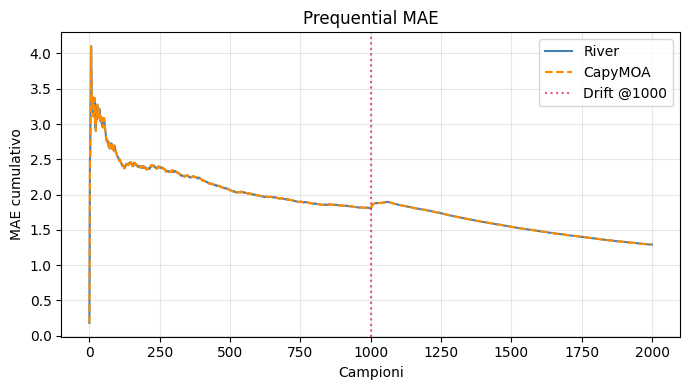

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(river_maes, label='River', color='steelblue', lw=1.5)
ax.plot(capymoa_maes, label='CapyMOA', color='darkorange', lw=1.5, ls='--')
ax.axvline(DRIFT_AT, color='crimson', ls=':', alpha=0.7, label=f'Drift @{DRIFT_AT}')
ax.set(xlabel='Campioni', ylabel='MAE cumulativo', title='Prequential MAE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tutte le modalità di foglia

### Senza bootstrap (deterministico)

Verifica l'equivalenza per `model` e `adaptive` — il caso `mean` è già coperto sopra.

Config                      MAE River  MAE CapyMOA      Δ MAE       corr  max|diff|     id/N
────────────────────────────────────────────────────────────────────────────────────────────
model,    no bootstrap       0.427230     0.427230   5.55e-17 1.00000000   2.66e-15  872/2000
adaptive, no bootstrap       0.393951     0.393951   5.55e-17 1.00000000   2.66e-15  937/2000

Config                       nodi R   nodi C   foglie R   foglie C
──────────────────────────────────────────────────────────────────
model,    no bootstrap           21       21OK          11         11OK
adaptive, no bootstrap           21       21OK          11         11OK


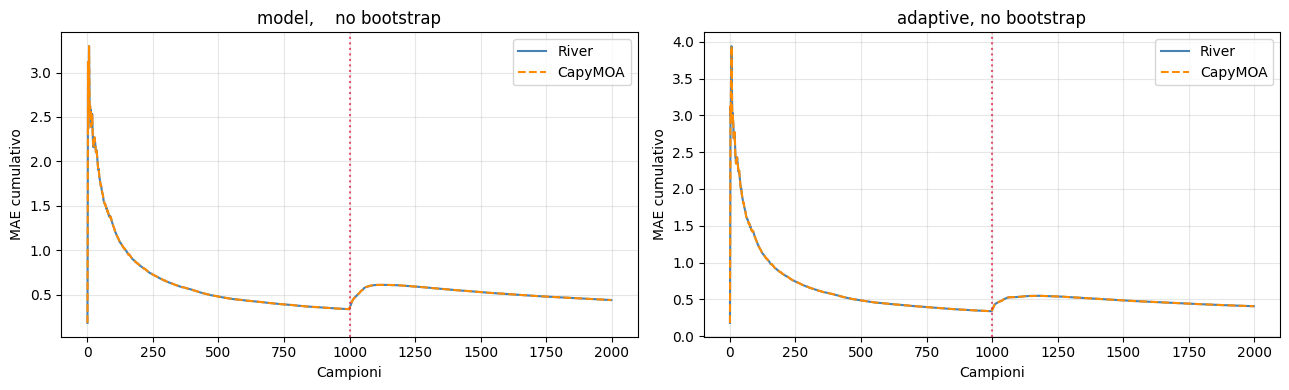

In [ ]:
SKIP = 10

det_configs = {
    'model,    no bootstrap': {'leaf_prediction': 'model',    'bootstrap_sampling': False},
    'adaptive, no bootstrap': {'leaf_prediction': 'adaptive', 'bootstrap_sampling': False},
}

det_results = {}
for label, overrides in det_configs.items():
    p = {**PARAMS, **overrides}

    rm = ud.build_river(p)
    cm = ud.build_capymoa(p, schema)

    rp, rm_maes = ud.run_river(rm, X, y, use_scaler=USE_SCALER, feature_names=feature_names)
    cp, cm_maes = run_capymoa(cm, X, y, schema, use_scaler=USE_SCALER)

    abs_diff_det = np.abs(rp - cp)
    mae_r = mean_absolute_error(y[SKIP:], rp[SKIP:])
    mae_c = mean_absolute_error(y[SKIP:], cp[SKIP:])
    corr_det, _ = pearsonr(rp[SKIP:], cp[SKIP:])

    rs       = rm.summary
    meas_det = ud.get_moa_struct(cm)

    det_results[label] = dict(
        mae_r=mae_r, mae_c=mae_c, corr=corr_det,
        max_diff=abs_diff_det.max(),
        n_identical=int(np.sum(abs_diff_det == 0)),
        r_nodes=rs.get('n_nodes'), c_nodes=meas_det.get('nodes'),
        r_leaves=rs.get('n_leaves'), c_leaves=meas_det.get('leaves'),
        rm_maes=rm_maes, cm_maes=cm_maes,
    )

print(f"{'Config':<26} {'MAE River':>10} {'MAE CapyMOA':>12} {'delta MAE':>10} "
      f"{'corr':>10} {'max|diff|':>10} {'id/N':>8}")
print('─' * 92)
for label, r in det_results.items():
    print(f"{label:<26} {r['mae_r']:>10.6f} {r['mae_c']:>12.6f} "
          f"{abs(r['mae_r']-r['mae_c']):>10.2e} {r['corr']:>10.8f} "
          f"{r['max_diff']:>10.2e} {r['n_identical']:>4}/{N}")

print()
print(f"{'Config':<26} {'nodi R':>8} {'nodi C':>8} {'foglie R':>10} {'foglie C':>10}")
print('─' * 66)
for label, r in det_results.items():
    mn = 'OK' if r['r_nodes'] == r['c_nodes'] else 'NO'
    ml = 'OK' if r['r_leaves'] == r['c_leaves'] else 'NO'
    print(f"{label:<26} {r['r_nodes']:>8} {r['c_nodes']:>8}{mn}  {r['r_leaves']:>10} {r['c_leaves']:>10}{ml}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (label, r) in zip(axes, det_results.items()):
    ax.plot(r['rm_maes'], label='River',   color='steelblue',  lw=1.5)
    ax.plot(r['cm_maes'], label='CapyMOA', color='darkorange', lw=1.5, ls='--')
    ax.axvline(DRIFT_AT, color='crimson', ls=':', alpha=0.7)
    ax.set(xlabel='Campioni', ylabel='MAE cumulativo', title=label)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Con bootstrap

Le predizioni puntuali divergono (RNG diversa), si confrontano le metriche aggregate.

Config                      MAE River  MAE CapyMOA      Δ MAE       corr  max|diff|
──────────────────────────────────────────────────────────────────────────────────
mean,     bootstrap          1.486743     1.429872   5.69e-02   0.886949     6.8942
model,    bootstrap          0.341920     0.353495   1.16e-02   0.995331     6.5340
adaptive, bootstrap          0.324799     0.342104   1.73e-02   0.994752     6.0545

Config                       nodi R   nodi C   foglie R   foglie C
──────────────────────────────────────────────────────────────────
mean,     bootstrap              31       35NO          16         18NO
model,    bootstrap              25       35NO          13         18NO
adaptive, bootstrap              25       35NO          13         18NO

Nota: con bootstrap_sampling=True i pesi Poisson differiscono (Python MT vs java.util.Random)
      -> confrontare solo metriche aggregate, non predizioni puntuali.


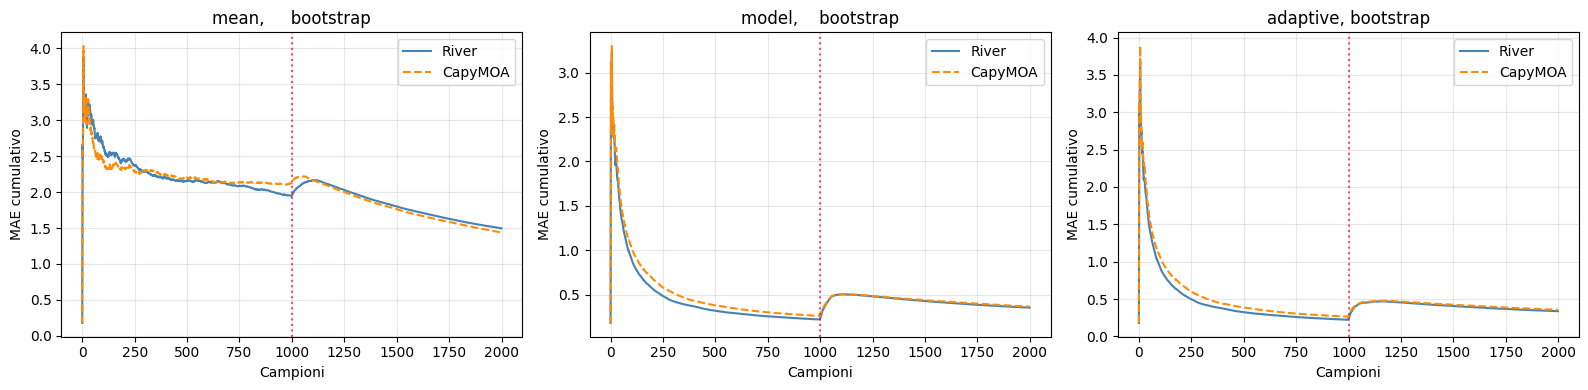

In [ ]:
boot_configs = {
    'mean,     bootstrap': {'leaf_prediction': 'mean',     'bootstrap_sampling': True},
    'model,    bootstrap': {'leaf_prediction': 'model',    'bootstrap_sampling': True},
    'adaptive, bootstrap': {'leaf_prediction': 'adaptive', 'bootstrap_sampling': True},
}

boot_results = {}
for label, overrides in boot_configs.items():
    p = {**PARAMS, **overrides}

    rm = ud.build_river(p)
    cm = ud.build_capymoa(p, schema)

    rp, rm_maes = ud.run_river(rm, X, y, use_scaler=USE_SCALER, feature_names=feature_names)
    cp, cm_maes = run_capymoa(cm, X, y, schema, use_scaler=USE_SCALER)

    abs_diff_b = np.abs(rp - cp)
    mae_r = mean_absolute_error(y[SKIP:], rp[SKIP:])
    mae_c = mean_absolute_error(y[SKIP:], cp[SKIP:])
    corr_b, _ = pearsonr(rp[SKIP:], cp[SKIP:])

    rs     = rm.summary
    meas_b = ud.get_moa_struct(cm)

    boot_results[label] = dict(
        mae_r=mae_r, mae_c=mae_c, corr=corr_b,
        max_diff=abs_diff_b.max(), mean_diff=abs_diff_b.mean(),
        r_nodes=rs.get('n_nodes'), c_nodes=meas_b.get('nodes'),
        r_leaves=rs.get('n_leaves'), c_leaves=meas_b.get('leaves'),
        rp=rp, cp=cp, rm_maes=rm_maes, cm_maes=cm_maes,
    )

print(f"{'Config':<26} {'MAE River':>10} {'MAE CapyMOA':>12} {'Δ MAE':>10} {'corr':>10} {'max|diff|':>10}")
print('─' * 82)
for label, r in boot_results.items():
    print(f"{label:<26} {r['mae_r']:>10.6f} {r['mae_c']:>12.6f} "
          f"{abs(r['mae_r']-r['mae_c']):>10.2e} {r['corr']:>10.6f} {r['max_diff']:>10.4f}")

print()
print(f"{'Config':<26} {'nodi R':>8} {'nodi C':>8} {'foglie R':>10} {'foglie C':>10}")
print('─' * 66)
for label, r in boot_results.items():
    mn = ' OK' if r['r_nodes'] == r['c_nodes'] else ' NO'
    ml = ' OK' if r['r_leaves'] == r['c_leaves'] else ' NO'
    print(f"{label:<26} {r['r_nodes']:>8} {r['c_nodes']:>8}{mn}  {r['r_leaves']:>10} {r['c_leaves']:>10}{ml}")

print()
print('Nota: con bootstrap_sampling=True i pesi Poisson differiscono (Python MT vs java.util.Random)')
print('      -> confrontare solo metriche aggregate, non predizioni puntuali.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, r) in zip(axes, boot_results.items()):
    ax.plot(r['rm_maes'], label='River',   color='steelblue',  lw=1.5)
    ax.plot(r['cm_maes'], label='CapyMOA', color='darkorange', lw=1.5, ls='--')
    ax.axvline(DRIFT_AT, color='crimson', ls=':', alpha=0.7)
    ax.set(xlabel='Campioni', ylabel='MAE cumulativo', title=label)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Casi particolari

### Feature nominali (> 2 valori)

In [ ]:
NOM_N, NOM_SEED = 2000, 42
rng_nom = np.random.RandomState(NOM_SEED)

nom_cat = rng_nom.choice(4, NOM_N)
nom_x = rng_nom.randn(NOM_N)
nom_y = nom_cat * 3.0 + nom_x * 0.1 + rng_nom.randn(NOM_N) * 0.2
# y dipende fortemente da cat → primo split atteso su cat

schema_nom = Schema.from_custom(
    features=['x_num', 'cat', 'y'],
    target='y',
    categories={'cat': ['c0', 'c1', 'c2', 'c3']},
    name='nominal_divergence'
)

river_nom = river_tree.HoeffdingAdaptiveTreeRegressor(
    grace_period=50, delta=1e-7, tau=0.05,
    leaf_prediction='mean', bootstrap_sampling=False,
    nominal_attributes=['cat'],
    drift_window_threshold=300, switch_significance=0.05, min_samples_split=5,
    drift_detector=river_drift.ADWIN(delta=0.002, clock=32), seed=0,
)

capymoa_nom = ud.build_capymoa(PARAMS, schema_nom)

r_preds_nom, c_preds_nom = [], []
for i in range(NOM_N):
    x_r  = {'x_num': float(nom_x[i]), 'cat': f'c{nom_cat[i]}'}
    arr  = np.array([nom_x[i], float(nom_cat[i])], dtype=float)
    inst = RegressionInstance(schema_nom, (arr, float(nom_y[i])))

    r_preds_nom.append(river_nom.predict_one(x_r) or 0.0)
    c_preds_nom.append(capymoa_nom.predict(inst) or 0.0)

    river_nom.learn_one(x_r, float(nom_y[i]))
    capymoa_nom.train(inst)

r_preds_nom = np.array(r_preds_nom)
c_preds_nom = np.array(c_preds_nom)
abs_diff_nom = np.abs(r_preds_nom - c_preds_nom)

rs_nom   = river_nom.summary
meas_nom = {m.getName(): m.getValue() for m in capymoa_nom.moa_learner.getModelMeasurements()}

SKIP_NOM = 10
mae_r_nom = mean_absolute_error(nom_y[SKIP_NOM:], r_preds_nom[SKIP_NOM:])
mae_c_nom = mean_absolute_error(nom_y[SKIP_NOM:], c_preds_nom[SKIP_NOM:])

print('Struttura finale degli alberi:')
print(f"{'':25} {'River':>10} {'CapyMOA':>10}  {'Match':>6}")
for label, r_val, c_val in [
    ('n_nodes',  rs_nom['n_nodes'],  int(meas_nom['tree nodes'])),
    ('n_leaves', rs_nom['n_leaves'], int(meas_nom['tree leaves'])),
]:
    print(f"  {label:<23} {r_val:>10} {c_val:>10}  {'OK' if r_val == c_val else 'NO'}")

print(f'\nMAE River: {mae_r_nom:.6f}')
print(f'MAE CapyMOA:  {mae_c_nom:.6f}')
print(f'Max |pred diff|:  {abs_diff_nom.max():.4f}')
print(f'Mean |pred diff|:  {abs_diff_nom.mean():.4f}')
print(f'Predizioni divergenti: {int(np.sum(abs_diff_nom > 1e-9))} / {NOM_N}')

Struttura finale degli alberi:
                               River    CapyMOA   Match
  n_nodes                         41         41  OK
  n_leaves                        22         22  OK

MAE River: 0.230352
MAE CapyMOA:  0.230352
Max |pred diff|:  0.0000
Mean |pred diff|:  0.0000
Predizioni divergenti: 0 / 2000


### `merit_preprune`

`merit_preprune=True` (default River) aggiunge il candidato *null split* alla lista dei candidati: se vince il test di Hoeffding, la foglia viene disattivata anziché crescere. Si verifica che River e CapyMOA concordino in entrambe le configurazioni.

In [13]:
MP_PARAMS = {**PARAMS, 'leaf_prediction': 'mean', 'bootstrap_sampling': False}

results = {}
for mp in [True, False]:
    label = f'preprune={mp}'

    rm = ud.build_river({**MP_PARAMS,
                         'leaf_prediction': MP_PARAMS['leaf_prediction'],
                         'bootstrap_sampling': MP_PARAMS['bootstrap_sampling']})
    rp, _ = ud.run_river(rm, X, y, feature_names=feature_names)

    cm = ud.build_capymoa_mp(MP_PARAMS, schema, merit_preprune=mp)
    cp, _ = ud.run_capymoa(cm, X, y, schema)

    abs_diff_mp = np.abs(rp - cp)
    mae_r = mean_absolute_error(y[SKIP:], rp[SKIP:])
    mae_c = mean_absolute_error(y[SKIP:], cp[SKIP:])

    results[label] = {
        'river_struct': ud.get_river_struct(rm),
        'capymoa_struct': ud.get_moa_struct(cm),
        'mae_river': mae_r,
        'mae_capymoa': mae_c,
        'max_diff': abs_diff_mp.max(),
        'n_identical': int(np.sum(abs_diff_mp == 0)),
    }

print(f"{'Config':<20} {'Metric':<18} {'River':>10} {'CapyMOA':>10}  {'Match':>6}")
print('─' * 68)
for label, r in results.items():
    rs, cs = r['river_struct'], r['capymoa_struct']
    for field in ['nodes', 'leaves', 'inactive']:
        rv, cv = rs[field], cs[field]
        match = 'OK' if rv == cv else 'NO'
        print(f"{label:<20} {field:<18} {rv:>10} {cv:>10}  {match:>6}")
    print(f"{label:<20} {'MAE':<18} {r['mae_river']:>10.6f} {r['mae_capymoa']:>10.6f}  "
          f"{'OK' if abs(r['mae_river']-r['mae_capymoa']) < 1e-8 else 'NO':>6}")
    print(f"{label:<20} {'max|diff|':<18} {r['max_diff']:>10.2e} "
          f"{'identical' if r['max_diff'] == 0 else 'divergent':>22}")
    print()

print('─' * 68)
print('Effetto di merit_preprune su struttura albero (River):')
for field in ['nodes', 'leaves', 'inactive']:
    vt = results['preprune=True']['river_struct'][field]
    vf = results['preprune=False']['river_struct'][field]
    print(f"  {field:<12}  True={vt:>4}  False={vf:>4}  delta={vf-vt:>+4}")

Config               Metric                  River    CapyMOA   Match
────────────────────────────────────────────────────────────────────
preprune=True        nodes                      25         25      OK
preprune=True        leaves                     13         13      OK
preprune=True        inactive                    0          0      OK
preprune=True        MAE                  1.535545   1.535545      OK
preprune=True        max|diff|            0.00e+00              identical

preprune=False       nodes                      25         25      OK
preprune=False       leaves                     13         13      OK
preprune=False       inactive                    0          0      OK
preprune=False       MAE                  1.535545   1.535545      OK
preprune=False       max|diff|            0.00e+00              identical

────────────────────────────────────────────────────────────────────
Effetto di merit_preprune su struttura albero (River):
  nodes         True=  25  

### Con feature continue `merit_preprune` è ininfluente

Il null split entra in gioco solo quando ci sono meno di 2 candidati reali — con feature numeriche continue questo non succede mai. L'esperimento sotto mostra il caso in cui ha effetto: feature categoriali con pochi campioni per valore (meno di `min_samples_split`).

In [14]:
NMP_N = 600
NMP_N_CATS = 60
NMP_MINSAMP = 20
NMP_GRACE = 50
NMP_SEED = 7

rng_nmp = np.random.RandomState(NMP_SEED)
cat_vals_nmp = rng_nmp.choice(NMP_N_CATS, NMP_N)
y_nmp  = rng_nmp.randn(NMP_N)

schema_nmp = Schema.from_custom(
    features=['cat', 'y'],
    target='y',
    categories={'cat': [str(i) for i in range(NMP_N_CATS)]},
    name='merit_preprune_demo'
)

nmp_params = {
    **MP_PARAMS,
    'grace_period': NMP_GRACE,
    'min_samples_split': NMP_MINSAMP,
}

nmp_results = {}
for mp in [True, False]:
    label = f'preprune={mp}'

    rm_nmp = river_tree.HoeffdingAdaptiveTreeRegressor(
        grace_period=NMP_GRACE, delta=MP_PARAMS['delta'], tau=0.05,
        leaf_prediction='mean', bootstrap_sampling=False,
        min_samples_split=NMP_MINSAMP, drift_window_threshold=300,
        switch_significance=0.05, model_selector_decay=0.95,
        drift_detector=river_drift.ADWIN(delta=0.002, clock=32),
        nominal_attributes=['cat'], merit_preprune=mp, seed=0,
    )
    for i in range(NMP_N):
        x = {'cat': int(cat_vals_nmp[i])}
        rm_nmp.predict_one(x)
        rm_nmp.learn_one(x, float(y_nmp[i]))

    cm_nmp = ud.build_capymoa_mp(nmp_params, schema_nmp, merit_preprune=mp)
    for i in range(NMP_N):
        arr  = np.array([float(cat_vals_nmp[i])], dtype=float)
        inst = RegressionInstance(schema_nmp, (arr, float(y_nmp[i])))
        cm_nmp.predict(inst)
        cm_nmp.train(inst)

    rs  = rm_nmp.summary
    ms  = {m.getName(): m.getValue() for m in cm_nmp.moa_learner.getModelMeasurements()}

    nmp_results[label] = {
        'river': {'leaves':   rs.get('n_leaves', 0),
                'active':   rs.get('n_active_leaves', 0),
                'inactive': rs.get('n_inactive_leaves', 0)},
        'capymoa': {'leaves':   int(ms.get('tree leaves', 0)),
                'active':   int(ms.get('tree leaves', 0)) - int(ms.get('inactive leaves', 0)),
                'inactive': int(ms.get('inactive leaves', 0))},
    }

print(f'Dataset: {NMP_N} campioni, {NMP_N_CATS} categorie '
      f'-> ~{NMP_N // NMP_N_CATS} campioni/valore, min_samples_split={NMP_MINSAMP}')
print(f'Ogni branch ha ~{NMP_N // NMP_N_CATS} < {NMP_MINSAMP} → merit=0 per tutti i candidati\n')
print(f"{'Config':<18} {'Metric':<12} {'River':>8} {'CapyMOA':>10}  {'Match':>6}")
print('─' * 56)
for label, r in nmp_results.items():
    for field in ['leaves', 'active', 'inactive']:
        rv = r['river'][field]
        cv = r['capymoa'][field]
        match = 'OK' if rv == cv else 'NO'
        print(f"{label:<18} {field:<12} {rv:>8} {cv:>10}  {match:>6}")
    print()

print('Atteso:')
print(f'  preprune=False -> ~{NMP_N_CATS} foglie  (split forzato: len=1, merit=0 non blocca il path len<2)')
print( '  preprune=True  ->  1 foglia   (merit=0 ≤ 0 -> should_split=False nel path len≥2)')

Dataset: 600 campioni, 60 categorie -> ~10 campioni/valore, min_samples_split=20
Ogni branch ha ~10 < 20 → merit=0 per tutti i candidati

Config             Metric          River    CapyMOA   Match
────────────────────────────────────────────────────────
preprune=True      leaves              1          1      OK
preprune=True      active              1          1      OK
preprune=True      inactive            0          0      OK

preprune=False     leaves             60         60      OK
preprune=False     active             60         60      OK
preprune=False     inactive            0          0      OK

Atteso:
  preprune=False -> ~60 foglie  (split forzato: len=1, merit=0 non blocca il path len<2)
  preprune=True  ->  1 foglia   (merit=0 ≤ 0 -> should_split=False nel path len≥2)


### Memory management

Ad ogni check il tree ordina le foglie per *promise* (campioni dall'ultimo split attempt),
mantiene attive le `maxActive` migliori e deattiva le restanti; foglie inattive con promise
alto vengono riattivate al check successivo.

In [40]:
MEM_N = 5000
MEM_GRACE = 50
MEM_PERIOD = 100
RIVER_MAX_SIZE   = 0.5   
CAPYMOA_MAX_SIZE = 0.1  

rng_m = np.random.RandomState(42)
X_m = rng_m.randn(MEM_N, 3).astype(np.float64)
y_m = 2*X_m[:,0] + 3*X_m[:,1] - X_m[:,2] + 0.1*rng_m.randn(MEM_N)

mem_base = {**PARAMS, 'leaf_prediction': 'mean', 'bootstrap_sampling': False,
            'grace_period': MEM_GRACE}

river_mem = river_tree.HoeffdingAdaptiveTreeRegressor(
    grace_period=MEM_GRACE, delta=PARAMS['delta'], tau=PARAMS['tau'],
    leaf_prediction='mean', bootstrap_sampling=False,
    drift_window_threshold=PARAMS['drift_window_threshold'],
    switch_significance=PARAMS['switch_significance'],
    min_samples_split=PARAMS['min_samples_split'],
    model_selector_decay=PARAMS['model_selector_decay'],
    drift_detector=river_drift.ADWIN(delta=PARAMS['adwin_delta'], clock=PARAMS['adwin_clock']),
    max_size=RIVER_MAX_SIZE,
    memory_estimate_period=MEM_PERIOD,
    seed=0,
)
capymoa_mem = ud.build_capymoa_mem(mem_base, schema,
                                   max_size_mb=CAPYMOA_MAX_SIZE,
                                   memory_estimate_period=MEM_PERIOD)

r_active, r_inactive = [], []
c_active, c_inactive = [], []
check_pts = []

for i in range(MEM_N):
    x_r = {f: float(X_m[i, j]) for j, f in enumerate(feature_names)}
    river_mem.predict_one(x_r)
    river_mem.learn_one(x_r, float(y_m[i]))

    inst = RegressionInstance(schema, (X_m[i], float(y_m[i])))
    capymoa_mem.predict(inst)
    capymoa_mem.train(inst)

    if (i + 1) % MEM_PERIOD == 0:
        rs = ud.get_river_struct(river_mem)
        cs = ud.get_moa_struct(capymoa_mem)
        r_active.append(rs['active'])
        r_inactive.append(rs['inactive'])
        c_active.append(cs['active'])
        c_inactive.append(cs['inactive'])
        check_pts.append(i + 1)

sizeof_ok = os.path.exists(SIZEOF_JAR)
rs_f = ud.get_river_struct(river_mem)
cs_f = ud.get_moa_struct(capymoa_mem)

print(f'sizeofag: {"ok" if sizeof_ok else "non caricato — CapyMOA inactive=0"}')
print(f"{'':22} {'max_size':>10} {'attive':>8} {'inattive':>10}")
print(f"{'River':22} {RIVER_MAX_SIZE:>8.1f} MB {rs_f['active']:>8d} {rs_f['inactive']:>10d}")
print(f"{'CapyMOA':22} {CAPYMOA_MAX_SIZE:>8.1f} MB {cs_f['active']:>8d} {cs_f['inactive']:>10d}")

sizeofag: ok
                         max_size   attive   inattive
River                       0.5 MB       43         11
CapyMOA                     0.1 MB       33         20


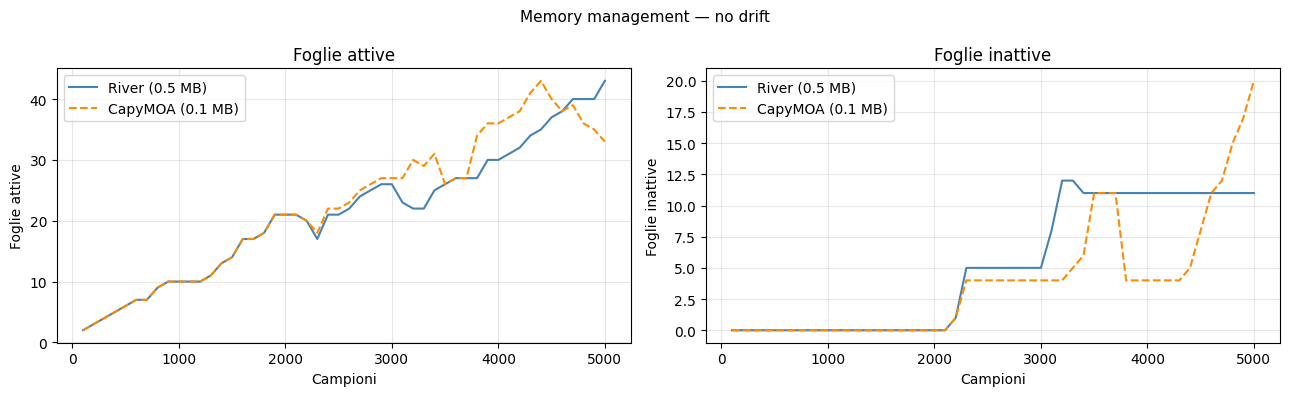

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(check_pts, r_active,   label=f'River ({RIVER_MAX_SIZE} MB)',
             color='steelblue', lw=1.5)
axes[0].plot(check_pts, c_active,   label=f'CapyMOA ({CAPYMOA_MAX_SIZE} MB)',
             color='darkorange', lw=1.5, ls='--')
axes[0].set(xlabel='Campioni', ylabel='Foglie attive', title='Foglie attive')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(check_pts, r_inactive, label=f'River ({RIVER_MAX_SIZE} MB)',
             color='steelblue', lw=1.5)
axes[1].plot(check_pts, c_inactive, label=f'CapyMOA ({CAPYMOA_MAX_SIZE} MB)',
             color='darkorange', lw=1.5, ls='--')
axes[1].set(xlabel='Campioni', ylabel='Foglie inattive', title='Foglie inattive')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Memory management — no drift', fontsize=11)
plt.tight_layout()
plt.show()

## Conclusioni

Il confronto sistematico su tutte le combinazioni di `leaf_prediction` × `bootstrap_sampling`:

- **Senza bootstrap** (mean, model, adaptive): predizioni identiche su tutto lo stream, struttura albero identica — le implementazioni sono equivalenti al livello numerico.
- **Con bootstrap**: le predizioni puntuali divergono per via dei generatori casuali diversi (Python MT vs `java.util.Random`), ma MAE e correlazione restano comparabili.
- **Feature nominali** (4 categorie, multiway split): struttura e predizioni identiche.
- **`merit_preprune`**: entrambe le configurazioni (True/False) concordano, sia su feature continue (dove il parametro è ininfluente) sia su feature categoriali sparse (dove disattiva le foglie).
- **Memory management**: entrambe le implementazioni deattivano le foglie meno
  promettenti quando il budget `max_size` è superato. I byte stimati differiscono (stima poco profonda vs heap reale).